In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

In [2]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Wheat"
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
num_class = 3
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 3781 files belonging to 3 classes.
Using 3025 files for training.
Found 3781 files belonging to 3 classes.
Using 756 files for validation.
Training dataset size: 95 batches
Validation dataset size: 12 batches
Test dataset size: 12 batches


In [3]:
class_names = train_dataset.class_names
class_names

['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']

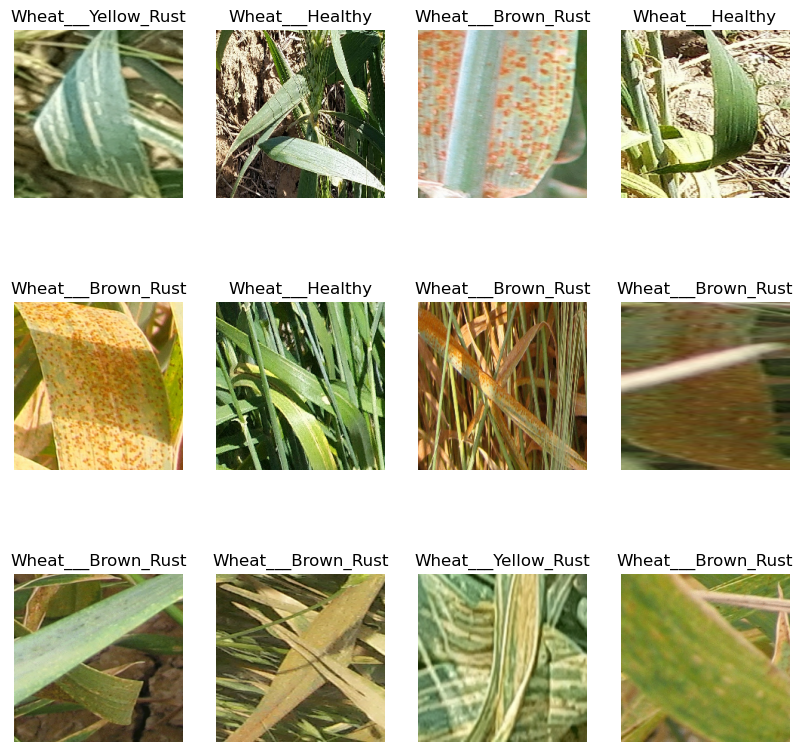

In [4]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

C:\Users\NAHID\AppData\Local\Temp\ipykernel_4764\2436110488.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")


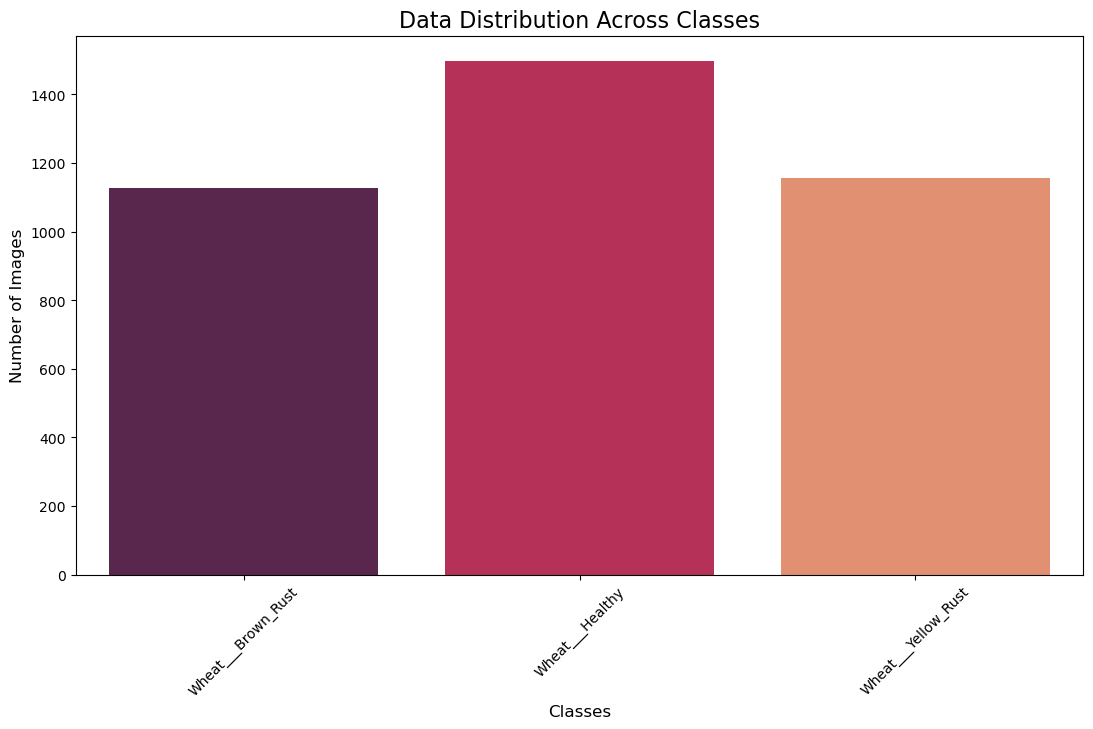

In [5]:
Data_imbalance = []
folder_names = []

# Iterate through each folder in the directory
for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        files = gb.glob(pathname=str(folder_path + "/*.*"))
        Data_imbalance.append(len(files))
        folder_names.append(folder)  # Collect folder names dynamically

# Plot the barplot with dynamic names
plt.figure(figsize=(13, 7))
sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")
plt.title("Data Distribution Across Classes", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if they are long
plt.show()

In [6]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))

Weight for class 0: 0.84
Weight for class 1: 0.63
Weight for class 2: 0.82


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [8]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

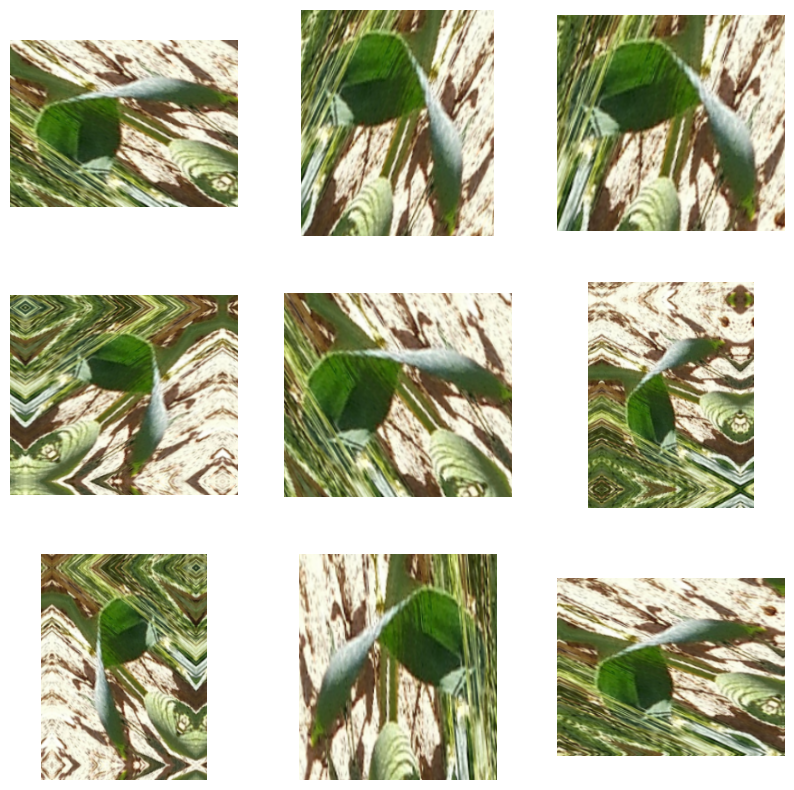

In [9]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[1]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

In [10]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

In [11]:
from tensorflow.keras import layers, models, Model, Sequential
from tensorflow.keras.optimizers import Adam
from vit_keras import vit

C:\Users\NAHID\anaconda3\envs\gpu3060\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
C:\Users\NAHID\anaconda3\envs\gpu3060\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
I

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [13]:
import tensorflow_hub as hub
import kagglehub

In [14]:
IMG_SHAPE = IMG_SIZE + (3,)
# Load ViT model
vit_base = vit.vit_b16(
    image_size=IMG_SIZE[0],      
    activation='softmax',     
    pretrained=True,         
    include_top=False,        
    pretrained_top=False,     
    classes=num_class    
)
vit_base.trainable = False

# Load DeiT model
deit_path = kagglehub.model_download("spsayakpaul/deit/tensorFlow2/base-distilled-patch16-224")
deit_base = hub.KerasLayer(deit_path, trainable=False)

# Define input layer
inp = layers.Input(shape=IMG_SHAPE)

# Apply data augmentation and resizing
x = data_augmentation(inp)
x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1])(x)

# Process through both ViT and DeiT
vit_features = vit_base(x)
deit_features = deit_base(x, training=True)

# Handle tuple output from DeiT if needed
if isinstance(deit_features, tuple):
    deit_features = deit_features[0]

# Concatenate features from both models
combined = layers.Concatenate()([vit_features, deit_features])

# Add classifier head
x = layers.Dropout(0.5)(combined)
x = layers.Dense(256, activation='gelu')(x)  # Increased neurons for combined features
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_class, activation='softmax')(x)

# Create hybrid model
hybrid_model = Model(inputs=inp, outputs=output)

# Compile the model
hybrid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Display model architecture
hybrid_model.summary()

C:\Users\NAHID\anaconda3\envs\gpu3060\lib\site-packages\vit_keras\utils.py:81: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 224, 224, 3)  0           ['input_2[0][0]']                
                                                                                                  
 resizing (Resizing)            (None, 224, 224, 3)  0           ['sequential[0][0]']             
                                                                                                  
 vit-b16 (Functional)           (None, 768)          85798656    ['resizing[0][0]']           

In [17]:
print("Training Hybrid ViT-DeiT Model...")
hybrid_history = hybrid_model.fit(
    train_dataset,
    class_weight=class_weight,
    validation_data=validation_dataset,
    epochs=10
)

Training Hybrid ViT-DeiT Model...
Epoch 1/10
95/95 [==============================] - 53s 551ms/step - loss: 0.0145 - accuracy: 0.9927 - val_loss: 0.0109 - val_accuracy: 0.9948
Epoch 2/10
95/95 [==============================] - 53s 551ms/step - loss: 0.0224 - accuracy: 0.9917 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 3/10
95/95 [==============================] - 53s 553ms/step - loss: 0.0282 - accuracy: 0.9894 - val_loss: 0.0030 - val_accuracy: 0.9974
Epoch 4/10
95/95 [==============================] - 53s 553ms/step - loss: 0.0412 - accuracy: 0.9884 - val_loss: 0.0519 - val_accuracy: 0.9844
Epoch 5/10
95/95 [==============================] - 52s 540ms/step - loss: 0.0287 - accuracy: 0.9891 - val_loss: 0.0038 - val_accuracy: 1.0000
Epoch 6/10
95/95 [==============================] - 52s 541ms/step - loss: 0.0253 - accuracy: 0.9911 - val_loss: 9.1677e-04 - val_accuracy: 1.0000
Epoch 7/10
95/95 [==============================] - 52s 538ms/step - loss: 0.0281 - accuracy: 0.9891 - v

In [20]:
print(f"Test dataset type: {type(test_dataset)}")  

for image, label in test_dataset.take(1):
    print(f"Sample image shape: {image.shape}, Sample label shape: {label.shape}")

# Initialize empty lists to store true labels and predicted labels
y_true = []
y_pred_classes = []

# Iterate through the test dataset to collect the true labels and predictions
for images, labels in test_dataset:
    # Collect true labels (convert to numpy array)
    y_true.extend(labels.numpy())
    
    # Make predictions using the model
    y_pred_prob = hybrid_model(images, training=False)  # Model predictions (probabilities)
    
    # Convert predicted probabilities to class labels (argmax along the class axis)
    y_pred_classes.extend(tf.argmax(y_pred_prob, axis=1).numpy())

# Convert y_true and y_pred_classes to NumPy arrays for compatibility with sklearn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Ensure the shape of the true and predicted labels are consistent
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred_classes: {y_pred_classes.shape}")

# Now, you can compute the precision, recall, and f1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
# Evaluate the model on the test dataset
test_loss, test_accuracy = hybrid_model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Test dataset type: <class 'tensorflow.python.data.ops.dataset_ops.ParallelMapDataset'>
Sample image shape: (32, 224, 224, 3), Sample label shape: (32,)
Shape of y_true: (372,)
Shape of y_pred_classes: (372,)
12/12 [==============================] - 6s 341ms/step - loss: 0.0018 - accuracy: 1.0000
Test Loss: 0.0018034841632470489
Test Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


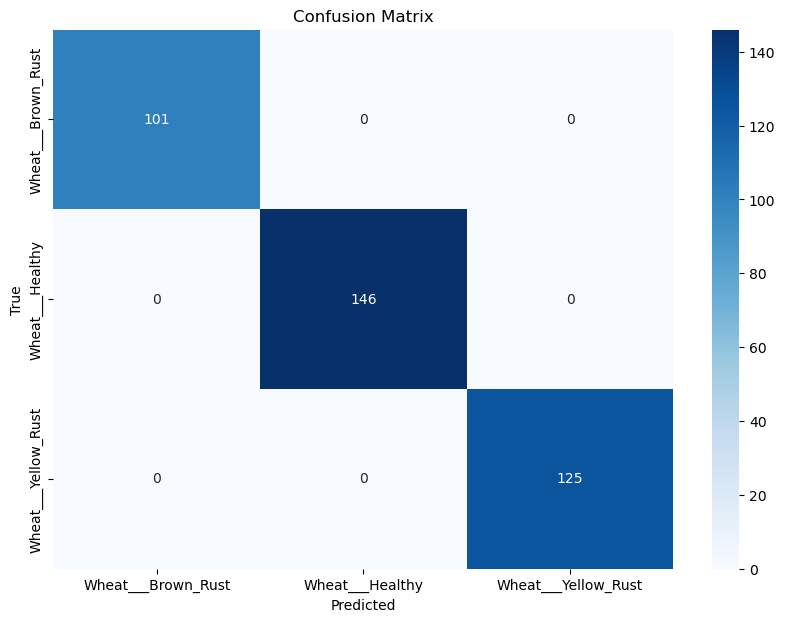

In [21]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

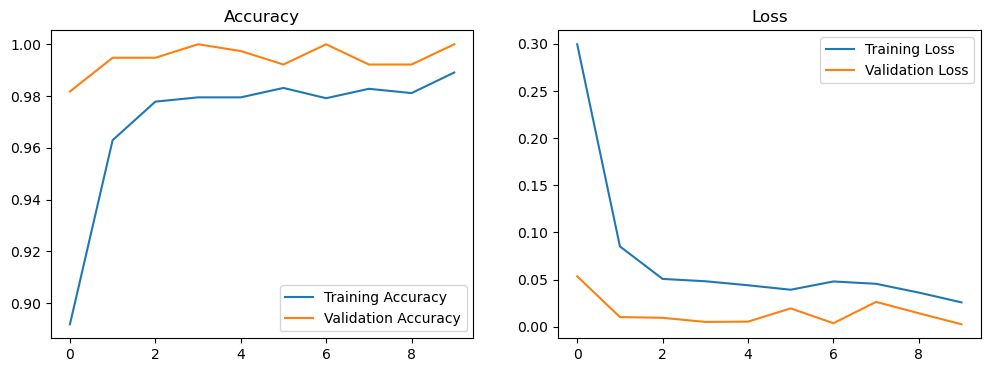

In [22]:
#Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hybrid_history.history['accuracy'], label='Training Accuracy')
plt.plot(hybrid_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hybrid_history.history['loss'], label='Training Loss')
plt.plot(hybrid_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
hybrid_model.save("wheat vit_hybrid_model", save_format="tf")